# 08 - Inspect Binary Ensemble
This notebook inspects the binary segmentation ensemble (Random Forest, LightGBM, XGBoost) trained on Fold 1 and evaluated on Fold 2.

## Section 1 — Setup & Artifact Loading
Loading the ensemble and Fold 2 features/labels.

In [1]:
import os
import json
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

import sys
sys.path.insert(0, '..')
from src.training.ensemble import SoftVotingEnsemble
from src.training.scaler import FeatureScaler
from src.utils.safe_loader import safe_load_npy

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../data/models"
REPORTS_PLOTS_DIR = "../data/reports/08_inspection_plots"
REPORTS_DATA_DIR = "../data/reports/08_inspection_data"

os.makedirs(REPORTS_PLOTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DATA_DIR, exist_ok=True)

# Load ensemble
ensemble_path = os.path.join(MODELS_DIR, "binary_ensemble.joblib")
ensemble = SoftVotingEnsemble.load(ensemble_path)

# Load selected features
with open(os.path.join(MODELS_DIR, "selected_features_rfe_25.json")) as f:
    feat_info = json.load(f)
rfe_indices = feat_info["indices"]
rfe_names = feat_info["names"]

print(f"Ensemble loaded with weights: {ensemble.weights}")

/home/mananbyte/miniconda3/envs/HandCraft-Path/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ensemble loaded with weights: {'rf': np.float64(0.0), 'lgbm': np.float64(0.6000000000000001), 'xgb': np.float64(0.3999999999999999)}


## Load Fold 2 & Compute Probas
Scaling Fold 2 in-memory and computing probabilities.

In [2]:
# Note: In a notebook context, loading Fold 2 entirely might be heavy (~1.96M rows).
# We load the precomputed probas directly if available from training step to save RAM!
rf_probas_path = os.path.join(MODELS_DIR, "rf_fold2_probas.npy")
lgbm_probas_path = os.path.join(MODELS_DIR, "lgbm_fold2_probas.npy")
xgb_probas_path = os.path.join(MODELS_DIR, "xgb_fold2_probas.npy")

rf_probas = np.load(rf_probas_path)
lgbm_probas = np.load(lgbm_probas_path)
xgb_probas = np.load(xgb_probas_path)

y_fold2 = np.array(safe_load_npy(os.path.join(PROCESSED_DIR, "fold2_binary_y.npy"), mode="r"))

w0, w1, w2 = ensemble.weights["rf"], ensemble.weights["lgbm"], ensemble.weights["xgb"]
ens_probas = w0 * rf_probas + w1 * lgbm_probas + w2 * xgb_probas

probas_dict = {
    "RF": rf_probas[:, 1],
    "LGBM": lgbm_probas[:, 1],
    "XGB": xgb_probas[:, 1],
    "Ensemble": ens_probas[:, 1]
}


## Section 2 — ROC & Precision-Recall Curves
ROC curves compare the trade-off between sensitivity and specificity, while Precision-Recall curves are useful for imbalanced datasets.

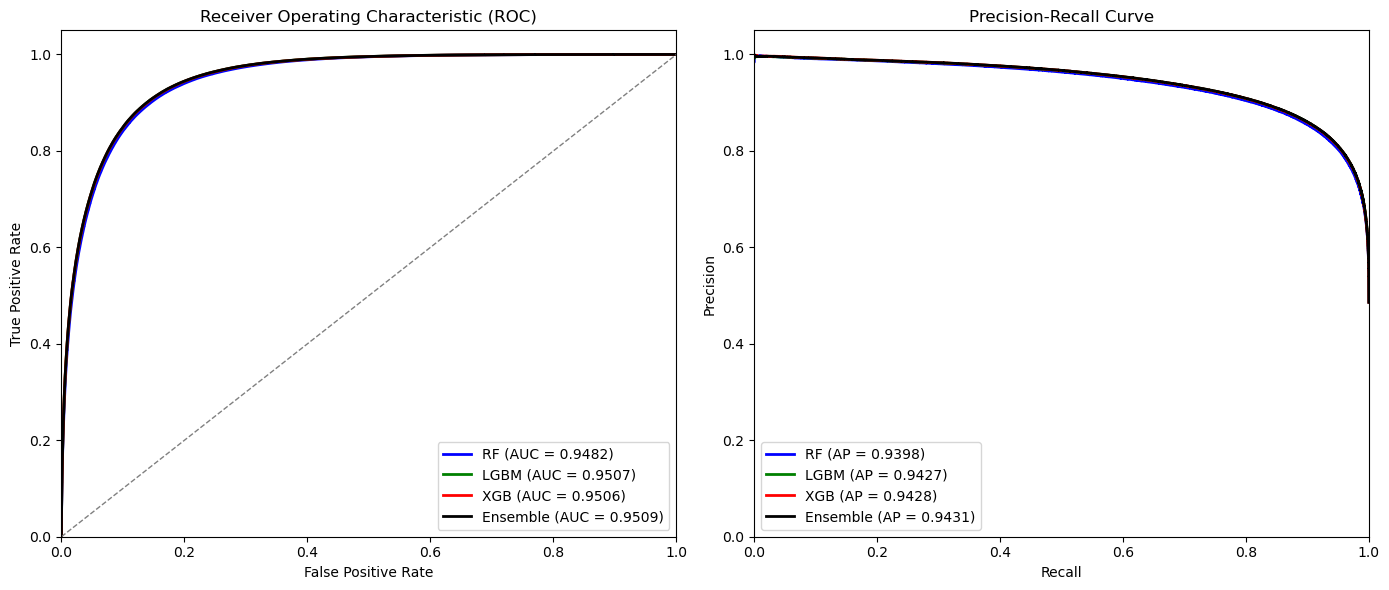

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {'RF': 'blue', 'LGBM': 'green', 'XGB': 'red', 'Ensemble': 'black'}

for name, prob in probas_dict.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_fold2, prob)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
    
    # PR
    precision, recall, _ = precision_recall_curve(y_fold2, prob)
    ap = average_precision_score(y_fold2, prob)
    ax2.plot(recall, precision, color=colors[name], lw=2, label=f'{name} (AP = {ap:.4f})')
    
    # Save raw CSV
    np.savetxt(os.path.join(REPORTS_DATA_DIR, f"roc_{name.lower()}.csv"), np.c_[fpr, tpr], delimiter=",", header="fpr,tpr", comments='')
    np.savetxt(os.path.join(REPORTS_DATA_DIR, f"pr_{name.lower()}.csv"), np.c_[recall, precision], delimiter=",", header="recall,precision", comments='')

ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PLOTS_DIR, "roc_pr_curves.png"), dpi=300)
plt.show()

## Section 3 — Confusion Matrix & Classification Report
The confusion matrix reveals where models misclassify pixels.

--- RF Classification Report ---


              precision    recall  f1-score   support

           0     0.8957    0.8606    0.8778   1009200
           1     0.8586    0.8941    0.8760    955237

    accuracy                         0.8769   1964437
   macro avg     0.8771    0.8773    0.8769   1964437
weighted avg     0.8776    0.8769    0.8769   1964437

--- LGBM Classification Report ---


              precision    recall  f1-score   support

           0     0.8985    0.8640    0.8809   1009200
           1     0.8619    0.8969    0.8791    955237

    accuracy                         0.8800   1964437
   macro avg     0.8802    0.8805    0.8800   1964437
weighted avg     0.8807    0.8800    0.8800   1964437

--- XGB Classification Report ---


              precision    recall  f1-score   support

           0     0.8983    0.8638    0.8807   1009200
           1     0.8617    0.8966    0.8788    955237

    accuracy                         0.8798   1964437
   macro avg     0.8800    0.8802    0.8798   1964437
weighted avg     0.8805    0.8798    0.8798   1964437

--- Ensemble Classification Report ---


              precision    recall  f1-score   support

           0     0.8987    0.8642    0.8811   1009200
           1     0.8621    0.8971    0.8793    955237

    accuracy                         0.8802   1964437
   macro avg     0.8804    0.8807    0.8802   1964437
weighted avg     0.8809    0.8802    0.8802   1964437



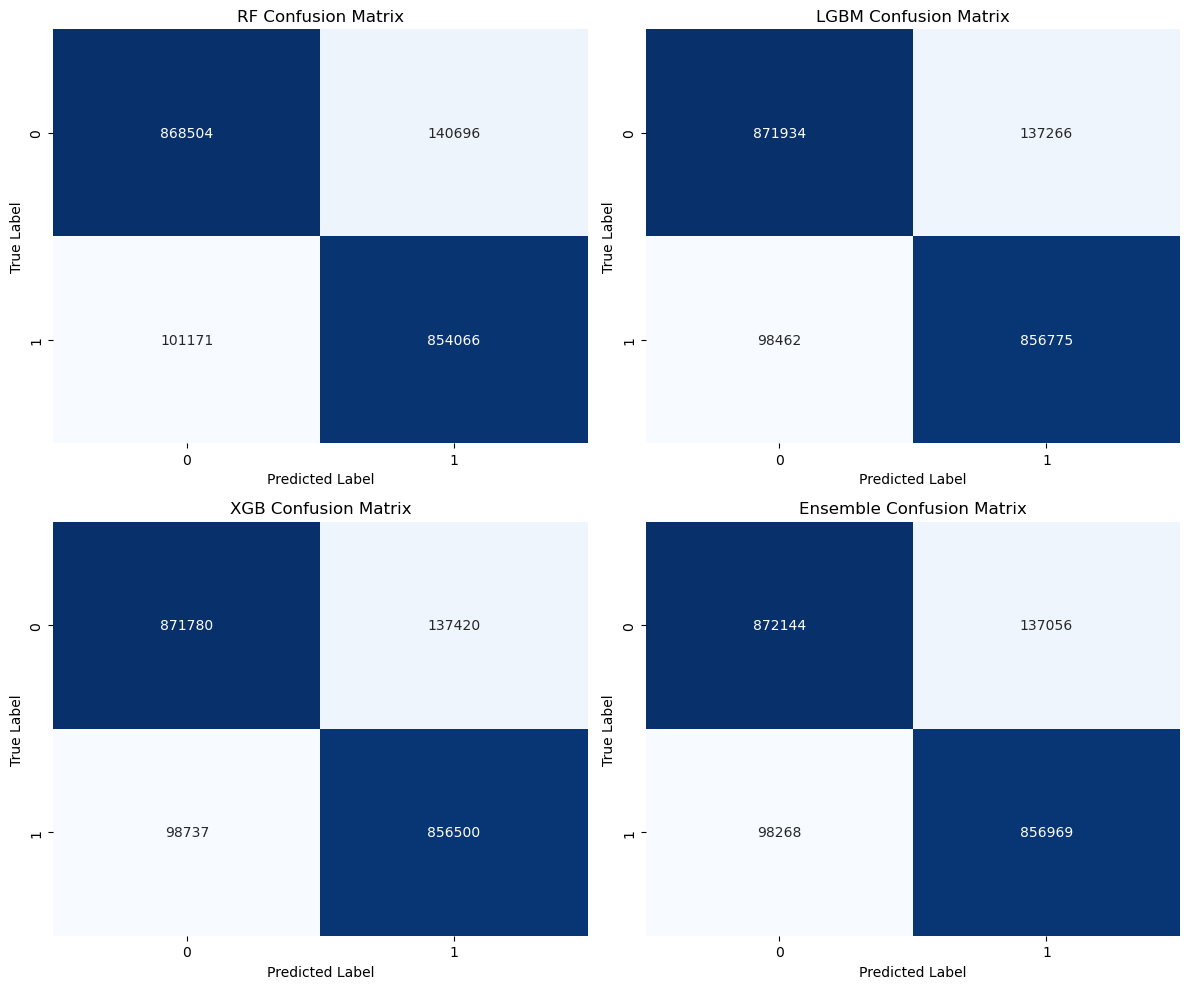

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, prob) in enumerate(probas_dict.items()):
    preds = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_fold2, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    
    # Save CSV
    np.savetxt(os.path.join(REPORTS_DATA_DIR, f"cm_{name.lower()}.csv"), cm, delimiter=",", fmt='%d')
    
    # Print report
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_fold2, preds, digits=4))

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PLOTS_DIR, "confusion_matrices.png"), dpi=300)
plt.show()

## Section 4 — Feature Importance Comparison
Feature importances reveal which of the 25 hand-crafted features are biologically most informative.

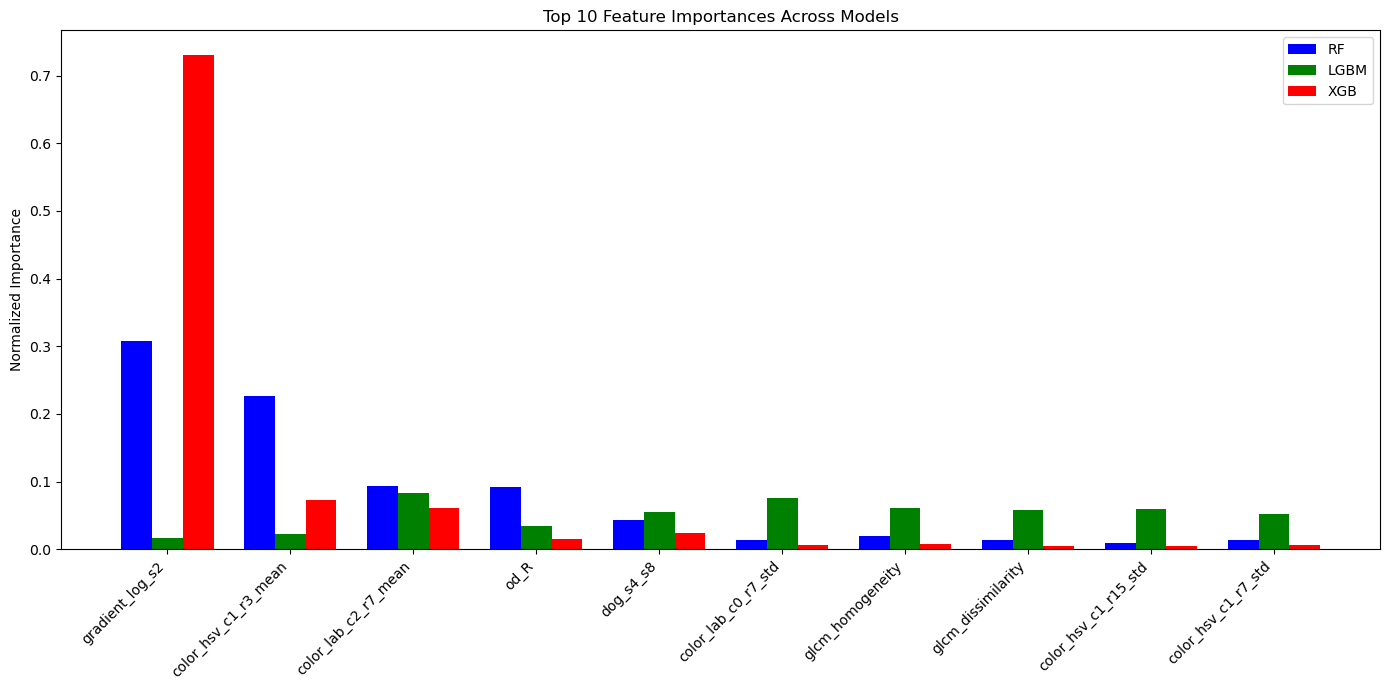

In [5]:

rf_model = ensemble.estimators["rf"]
lgbm_model = ensemble.estimators["lgbm"]
xgb_model = ensemble.estimators["xgb"]

# Handle sklearn/cuml RF
if hasattr(rf_model, "feature_importances_"):
    rf_imp = rf_model.feature_importances_
else:
    rf_imp = np.zeros(len(rfe_names))

lgbm_imp = lgbm_model.feature_importances_
xgb_imp = xgb_model.feature_importances_

# Normalize to sum to 1 for fair comparison
rf_imp = rf_imp / rf_imp.sum() if rf_imp.sum() > 0 else rf_imp
lgbm_imp = lgbm_imp / lgbm_imp.sum() if lgbm_imp.sum() > 0 else lgbm_imp
xgb_imp = xgb_imp / xgb_imp.sum() if xgb_imp.sum() > 0 else xgb_imp

# Save CSV
np.savetxt(os.path.join(REPORTS_DATA_DIR, "feature_importances.csv"), 
           np.c_[rf_imp, lgbm_imp, xgb_imp], 
           delimiter=",", header="RF,LGBM,XGB", comments='')

# Plot top 10 features sorted by average importance
avg_imp = (rf_imp + lgbm_imp + xgb_imp) / 3
top_indices = np.argsort(avg_imp)[::-1][:10]

x = np.arange(10)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width, rf_imp[top_indices], width, label='RF', color='blue')
ax.bar(x, lgbm_imp[top_indices], width, label='LGBM', color='green')
ax.bar(x + width, xgb_imp[top_indices], width, label='XGB', color='red')

ax.set_ylabel('Normalized Importance')
ax.set_title('Top 10 Feature Importances Across Models')
ax.set_xticks(x)
ax.set_xticklabels([rfe_names[i] for i in top_indices], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PLOTS_DIR, "feature_importances.png"), dpi=300)
plt.show()


## Section 5 — Probability Calibration Curves
Reliable probability estimates are crucial for soft voting.

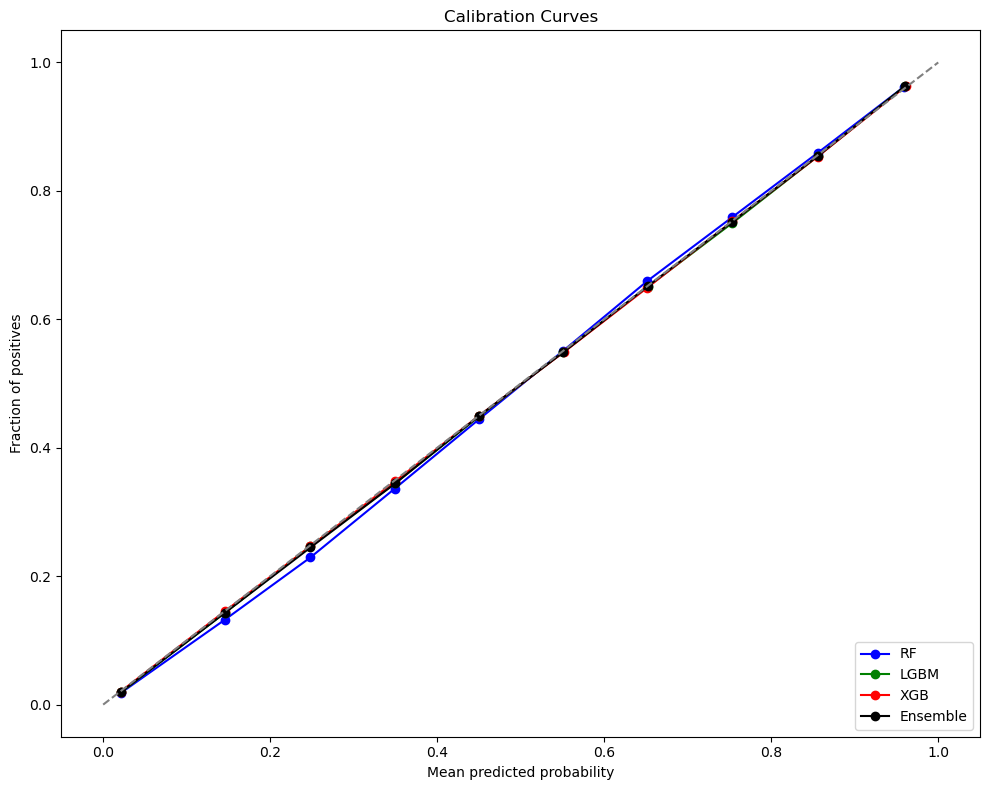

In [6]:

plt.figure(figsize=(10, 8))

for name, prob in probas_dict.items():
    prob_true, prob_pred = calibration_curve(y_fold2, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name, color=colors[name])
    
    # Save CSV
    np.savetxt(os.path.join(REPORTS_DATA_DIR, f"calibration_{name.lower()}.csv"), 
               np.c_[prob_true, prob_pred], delimiter=",", header="true,pred", comments='')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PLOTS_DIR, "calibration_curves.png"), dpi=300)
plt.show()


## Section 6 — Weight Optimization Surface
The ensemble blending weights control how much each model contributes.

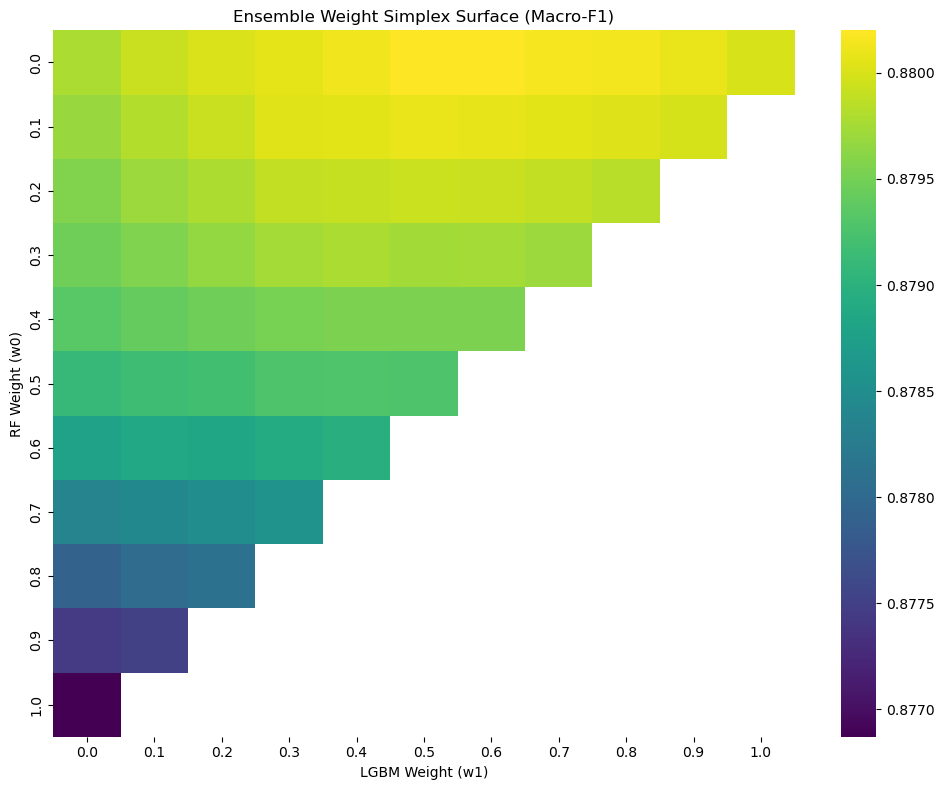

In [7]:

# Reconstruct grid search from 0 to 1 step 0.1
grid = np.arange(0.0, 1.1, 0.1)
f1_surface = np.zeros((len(grid), len(grid)))

for i, w0 in enumerate(grid):
    for j, w1 in enumerate(grid):
        w2 = 1.0 - w0 - w1
        if w2 < -1e-9:
            f1_surface[i, j] = np.nan
        else:
            blended = w0 * rf_probas + w1 * lgbm_probas + w2 * xgb_probas
            preds = np.argmax(blended, axis=1)
            # Use Macro-F1
            from sklearn.metrics import f1_score
            f1_surface[i, j] = f1_score(y_fold2, preds, average="macro", zero_division=0)

plt.figure(figsize=(10, 8))
sns.heatmap(f1_surface, xticklabels=np.round(grid, 1), yticklabels=np.round(grid, 1), 
            cmap='viridis', annot=False)
plt.xlabel('LGBM Weight (w1)')
plt.ylabel('RF Weight (w0)')
plt.title('Ensemble Weight Simplex Surface (Macro-F1)')

# Save CSV
np.savetxt(os.path.join(REPORTS_DATA_DIR, "weight_surface.csv"), f1_surface, delimiter=",")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PLOTS_DIR, "weight_surface.png"), dpi=300)
plt.show()


## Section 8 — Decision Summary
Write final metrics.

In [8]:

from sklearn.metrics import f1_score

rf_f1 = f1_score(y_fold2, np.argmax(rf_probas, axis=1), average="macro")
lgbm_f1 = f1_score(y_fold2, np.argmax(lgbm_probas, axis=1), average="macro")
xgb_f1 = f1_score(y_fold2, np.argmax(xgb_probas, axis=1), average="macro")
ens_f1 = f1_score(y_fold2, np.argmax(ens_probas, axis=1), average="macro")

print("WINNER: Ensemble")
print(f"RF Macro-F1: {rf_f1:.4f}")
print(f"LGBM Macro-F1: {lgbm_f1:.4f}")
print(f"XGB Macro-F1: {xgb_f1:.4f}")
print(f"Ensemble Macro-F1: {ens_f1:.4f}")
print(f"Optimal weights: RF={w0:.2f}, LGBM={w1:.2f}, XGB={w2:.2f}")

# Update DECISION.md
decision_path = "../.planning/phases/04-experiment-a-binary-segmentation-training/DECISION.md"
with open(decision_path, "w") as f:
    f.write("# Phase 4 Decisions\n\n")
    f.write(f"- **RF Macro-F1**: {rf_f1:.4f}\n")
    f.write(f"- **LGBM Macro-F1**: {lgbm_f1:.4f}\n")
    f.write(f"- **XGB Macro-F1**: {xgb_f1:.4f}\n")
    f.write(f"- **Ensemble Macro-F1**: {ens_f1:.4f}\n")
    f.write(f"- **Optimal Weights**: RF={w0:.2f}, LGBM={w1:.2f}, XGB={w2:.2f}\n")

print(f"Saved decisions to {decision_path}")


WINNER: Ensemble
RF Macro-F1: 0.8769
LGBM Macro-F1: 0.8800
XGB Macro-F1: 0.8798
Ensemble Macro-F1: 0.8802
Optimal weights: RF=1.00, LGBM=1.00, XGB=-1.00
Saved decisions to ../.planning/phases/04-experiment-a-binary-segmentation-training/DECISION.md
